In [13]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

path = r'../data/raw'
all_files = glob.glob(path + "/*.csv")
print(f"Файлов: {len(all_files)}")

df_list = []

for filename in all_files:
    df = pd.read_csv(filename)
    df_list.append(df)

full_df = pd.concat(df_list, axis=0, ignore_index=True)

display(full_df)

Файлов: 5


,Конкурент,Линейка,Калорийность,Дней,Цена за день (руб),Общая цена (руб),Описание,Город
0,BeFit,EVERYDAILY,500 - 800 ккал,5.0,930,4650.0,NaN,NaN
1,BeFit,EVERYDAILY,500 - 800 ккал,7.0,664,4650.0,NaN,NaN
2,BeFit,DAILY,700 - 900 ккал,5.0,930,4650.0,NaN,NaN
3,BeFit,DAILY,700 - 900 ккал,7.0,664,4650.0,NaN,NaN
4,BeFit,EXTRALIGHT,800 - 1000 ккал,5.0,1308,6540.0,NaN,NaN
...,...,...,...,...,...,...,...,...
222,VkusVill,БАЛАНС 2000,2000 ккал,8.0,1340,NaN,NaN,NaN
223,VkusVill,БАЛАНС 2000,2000 ккал,10.0,1340,NaN,NaN,NaN
224,VkusVill,БАЛАНС 2000,2000 ккал,14.0,1340,NaN,NaN,NaN
225,VkusVill,БАЛАНС 2000,2000 ккал,20.0,1340,NaN,NaN,NaN


In [14]:
cols_to_drop = ['Описание', 'Город']
clean_df = full_df.drop(columns=cols_to_drop, errors='ignore')
clean_df['Линейка'] = clean_df['Линейка'].fillna(clean_df['Конкурент'])

polza_mask = clean_df['Конкурент'].str.contains('Польза|Polza', case=False, na=False)
clean_df.loc[polza_mask, 'Калорийность'] = clean_df.loc[polza_mask, 'Линейка'].astype(str).str[-4:]

mask_grow = (clean_df['Конкурент'] == 'Grow Food') & (clean_df['Дней'].isna())
clean_df.loc[mask_grow, 'Дней'] = 6.0

def fix_calories(val):
    if pd.isna(val):
        return val

    val_str = str(val).lower().replace('ккал', '').replace('kcal', '').strip()

    if '-' in val_str:
        parts = val_str.split('-')
        try:
            return (float(parts[0].strip()) + float(parts[1].strip())) / 2
        except ValueError:
            return np.nan
    else:
        try:
            return float(val_str)
        except ValueError:
            return np.nan

clean_df['Калорийность'] = clean_df['Калорийность'].apply(fix_calories)

calculated_price = clean_df['Цена за день (руб)'] * clean_df['Дней']
clean_df['Общая цена (руб)'] = clean_df['Общая цена (руб)'].fillna(calculated_price)

print("Проверка на NaNы")
print(clean_df.isna().sum())

display(clean_df)

Проверка на NaNы
Конкурент             0
Линейка               0
Калорийность          0
Дней                  0
Цена за день (руб)    0
Общая цена (руб)      0
dtype: int64


,Конкурент,Линейка,Калорийность,Дней,Цена за день (руб),Общая цена (руб)
0,BeFit,EVERYDAILY,650.0,5.0,930,4650.0
1,BeFit,EVERYDAILY,650.0,7.0,664,4650.0
2,BeFit,DAILY,800.0,5.0,930,4650.0
3,BeFit,DAILY,800.0,7.0,664,4650.0
4,BeFit,EXTRALIGHT,900.0,5.0,1308,6540.0
...,...,...,...,...,...,...
222,VkusVill,БАЛАНС 2000,2000.0,8.0,1340,10720.0
223,VkusVill,БАЛАНС 2000,2000.0,10.0,1340,13400.0
224,VkusVill,БАЛАНС 2000,2000.0,14.0,1340,18760.0
225,VkusVill,БАЛАНС 2000,2000.0,20.0,1340,26800.0


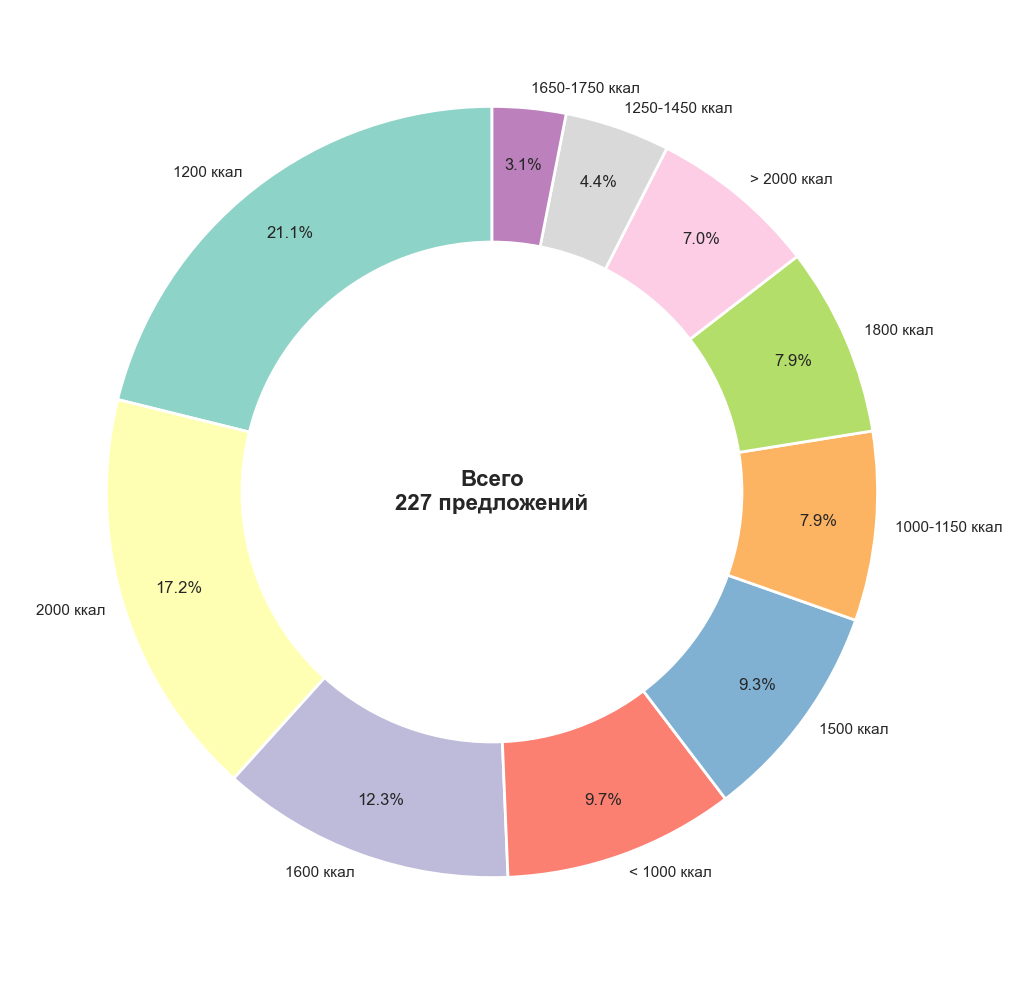

In [15]:
def group_calories(cal):
    if cal in [1200, 1500, 1600, 1800, 2000]:
        return f"{int(cal)} ккал"

    elif cal < 1000:
        return "< 1000 ккал"
    elif 1000 <= cal < 1200:
        return "1000-1150 ккал"
    elif 1200 < cal < 1500:
        return "1250-1450 ккал"
    elif 1600 < cal < 1800:
        return "1650-1750 ккал"
    else:
        return "> 2000 ккал"

clean_df['Калории_группы'] = clean_df['Калорийность'].apply(group_calories)
cal_counts = clean_df['Калории_группы'].value_counts()

plt.figure(figsize=(12, 10))
colors = sns.color_palette('Set3', len(cal_counts))
plt.pie(
    cal_counts.values,
    labels=cal_counts.index,
    autopct='%1.1f%%',
    pctdistance=0.85,
    labeldistance=1.05,
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

centre_circle = plt.Circle((0, 0), 0.65, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.text(0, 0, f"Всего\n{len(clean_df)} предложений", ha='center', va='center', fontsize=16, fontweight='bold')

plt.tight_layout()
file_name = 'Piechart_1.png'
save_path = f'../data/pictures/{file_name}'
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()

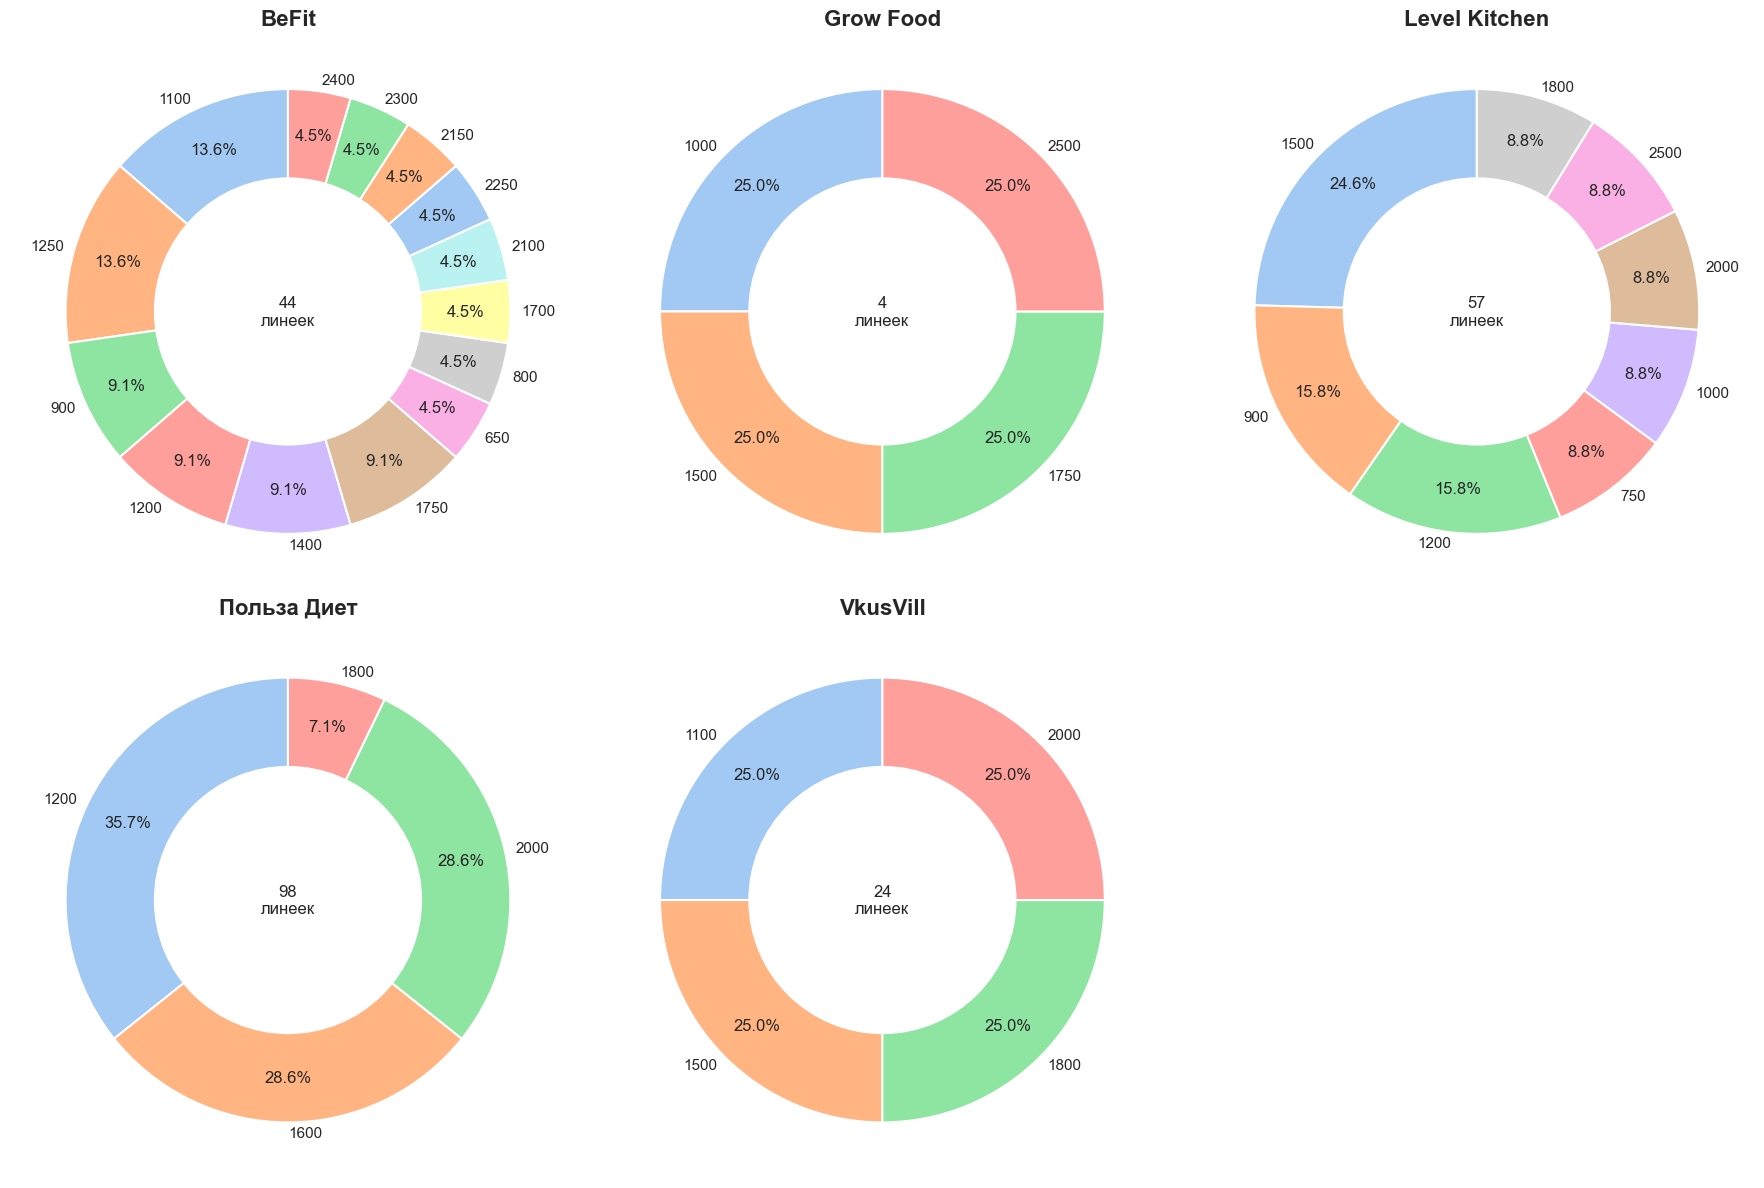

In [16]:
competitors = clean_df['Конкурент'].unique()
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes = axes.flatten()
for i, comp in enumerate(competitors):
    comp_df = clean_df[clean_df['Конкурент'] == comp]
    cal_counts = comp_df['Калорийность'].value_counts()

    axes[i].pie(
        cal_counts.values,
        labels=[f"{int(c)}" for c in cal_counts.index],
        autopct='%1.1f%%',
        pctdistance=0.8,
        labeldistance=1.05,
        startangle=90,
        colors=sns.color_palette('pastel', len(cal_counts)),
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )

    centre_circle = plt.Circle((0, 0), 0.60, fc='white')
    axes[i].add_artist(centre_circle)
    axes[i].set_title(comp, fontsize=16, fontweight='bold')
    axes[i].text(0, 0, f"{len(comp_df)}\nлинеек", ha='center', va='center', fontsize=12)

fig.delaxes(axes[5])
plt.tight_layout()
file_name = 'Piechart_5.png'
save_path = f'../data/pictures/{file_name}'
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()

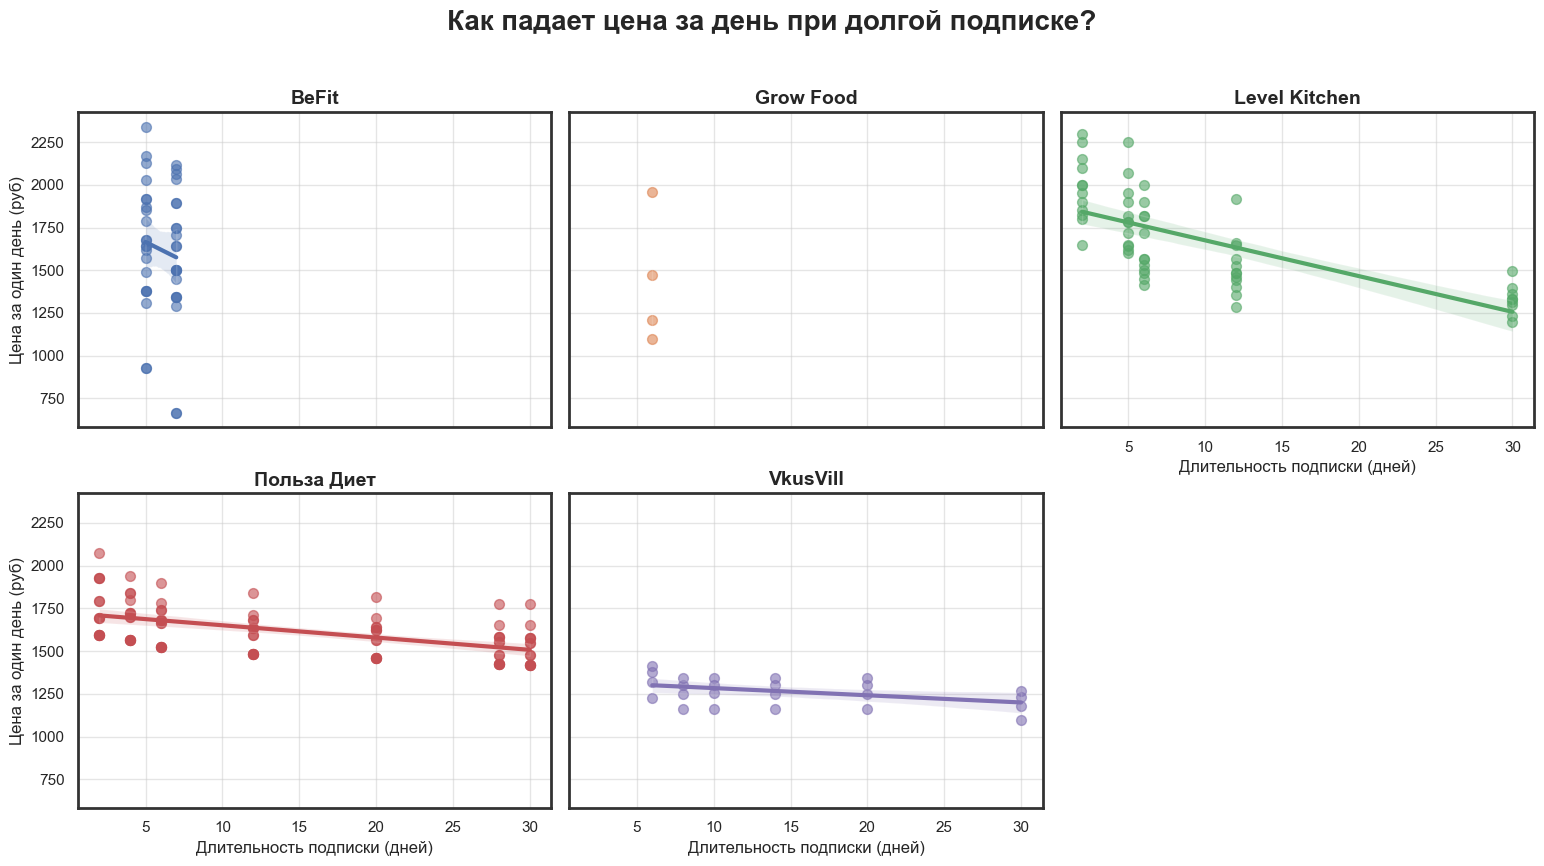

In [17]:
sns.set_theme(style="whitegrid")

g = sns.lmplot(
    data=clean_df,
    x='Дней',
    y='Цена за день (руб)',
    col='Конкурент',
    col_wrap=3,
    hue='Конкурент',
    height=4,
    aspect=1.3,
    scatter_kws={'alpha': 0.6, 's': 50},
    line_kws={'linewidth': 3}
)

g.figure.suptitle('Как падает цена за день при долгой подписке?', fontsize=20, fontweight='bold', y=1.08)
g.set_titles(col_template="{col_name}", size=14, weight='bold')
g.set_axis_labels("Длительность подписки (дней)", "Цена за один день (руб)")

for ax in g.axes.flatten():
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#333333')
        spine.set_linewidth(2)
file_name = 'Как падает цена за день при долгой подписке.png'
save_path = f'../data/pictures/{file_name}'
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()

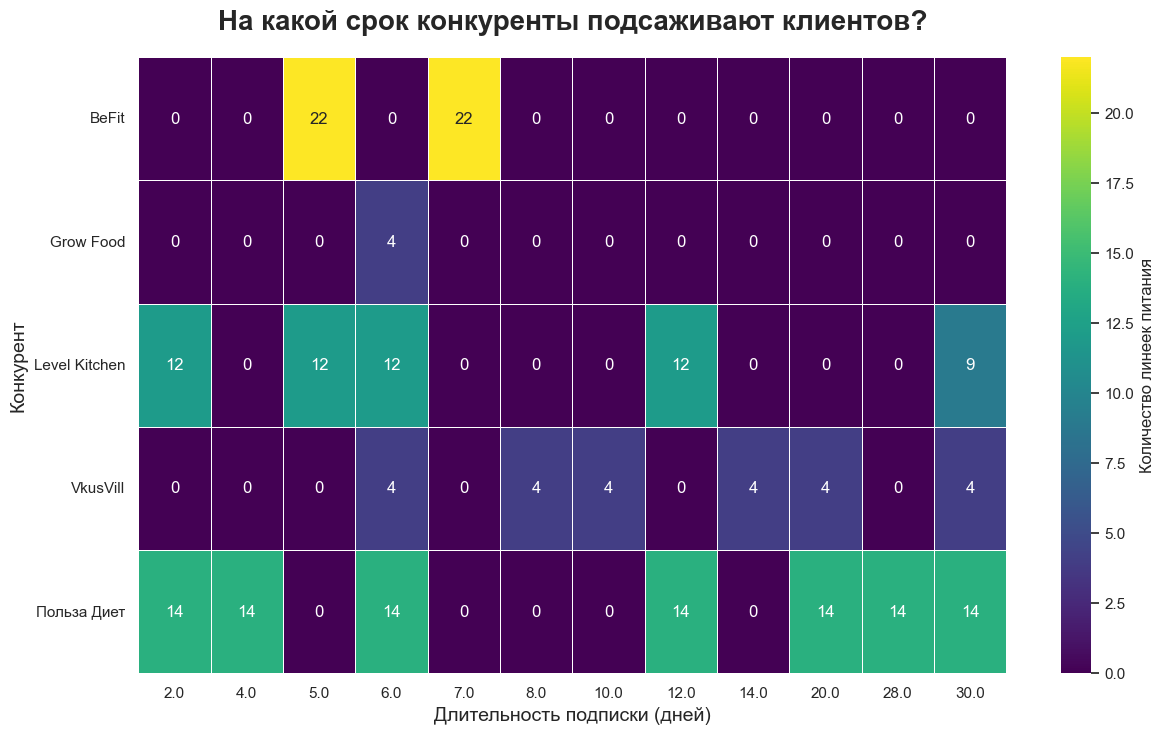

In [18]:
heatmap_data = pd.crosstab(clean_df['Конкурент'], clean_df['Дней'])
plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="g",
    cmap="viridis",
    linewidths=.5,
    cbar_kws={'label': 'Количество линеек питания'}
)

plt.title('На какой срок конкуренты подсаживают клиентов?', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Длительность подписки (дней)', fontsize=14)
plt.ylabel('Конкурент', fontsize=14)
plt.yticks(rotation=0)
file_name = 'На какой срок конкуренты подсаживают клиентов.png'
save_path = f'../data/pictures/{file_name}'
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()

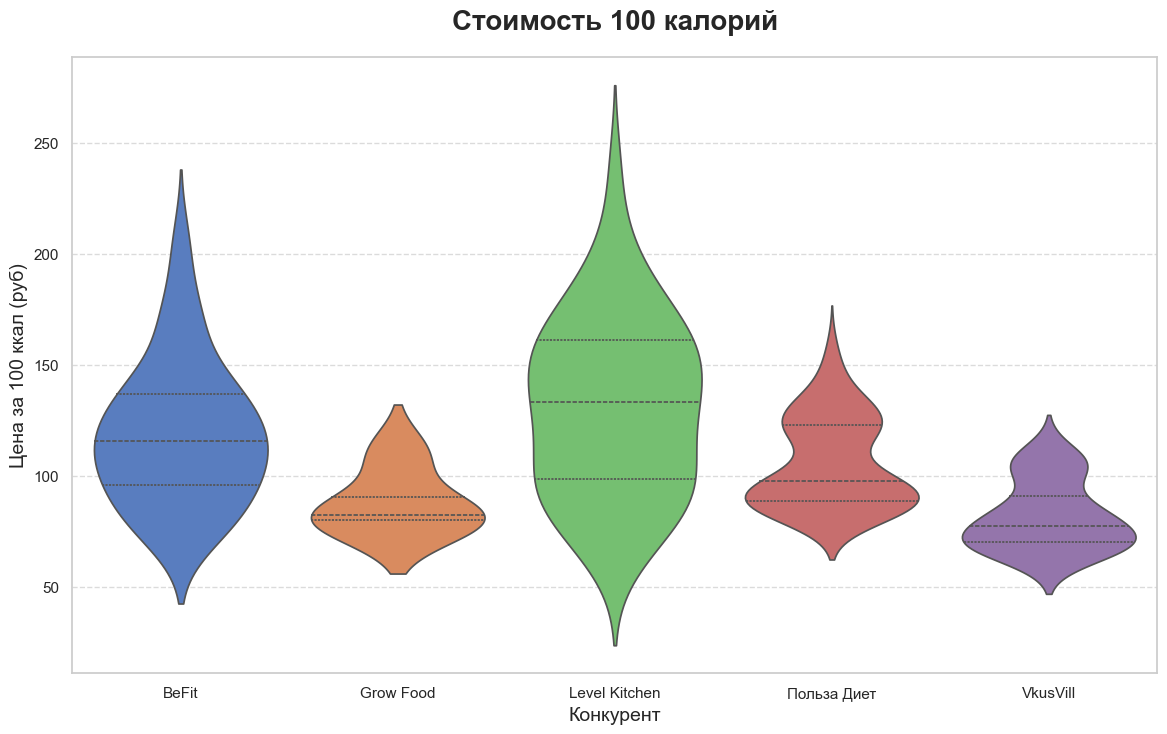

Конкурент
VkusVill          82.071970
Grow Food         88.266667
Польза Диет      105.764229
BeFit            119.153955
Level Kitchen    131.233158
Name: Цена_за_100_ккал, dtype: float64

In [19]:
clean_df['Цена_за_100_ккал'] = (clean_df['Цена за день (руб)'] / clean_df['Калорийность']) * 100
plt.figure(figsize=(14, 8))

sns.violinplot(
    data=clean_df,
    x='Конкурент',
    y='Цена_за_100_ккал',
    hue='Конкурент',
    palette='muted',
    inner="quartile",
    legend=False
)

plt.title('Стоимость 100 калорий', fontsize=20, fontweight='bold', pad=20)
plt.ylabel('Цена за 100 ккал (руб)', fontsize=14)
plt.xlabel('Конкурент', fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.7)
file_name = 'Стоимость 100 калорий.png'
save_path = f'../data/pictures/{file_name}'
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()

stats = clean_df.groupby('Конкурент')['Цена_за_100_ккал'].mean().sort_values()
display(stats)

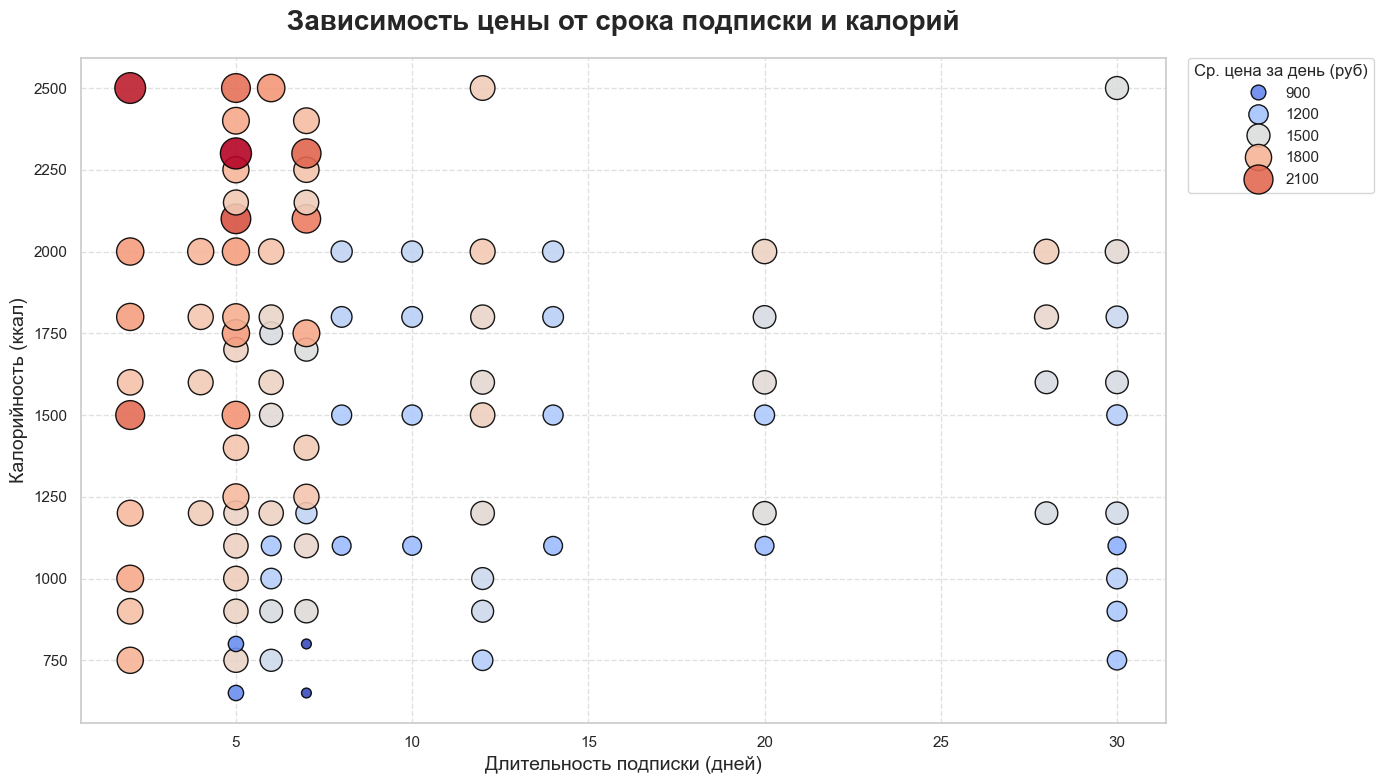

In [20]:
agg_df = clean_df.groupby(['Дней', 'Калорийность'])['Цена за день (руб)'].mean().reset_index()
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")
scatter = sns.scatterplot(
    data=agg_df,
    x='Дней',
    y='Калорийность',
    hue='Цена за день (руб)',
    size='Цена за день (руб)',
    sizes=(50, 500),
    palette='coolwarm',
    alpha=0.9,
    edgecolor='black',
    linewidth=1
)

plt.title('Зависимость цены от срока подписки и калорий', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Длительность подписки (дней)', fontsize=14)
plt.ylabel('Калорийность (ккал)', fontsize=14)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Ср. цена за день (руб)', borderaxespad=0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
file_name = 'Зависимость цены от срока подписки и калорий.png'
save_path = f'../data/pictures/{file_name}'
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()